# Data Profiling

### 1. Hubungkan (Mount) Google Drive
Jalankan kode di bawah ini. Anda akan diminta untuk memberikan izin akses ke Google Drive Anda.

### 2. Membuka Dataset
Setelah Drive terhubung, gunakan library `pandas` untuk membaca file. Pastikan Anda mengubah `path_file` sesuai dengan lokasi file Anda di Drive.

In [1]:
import pandas as pd

# Contoh: Membuka file CSV
# Ganti 'nama_folder/dataset.csv' dengan folder dan nama file Anda yang sebenarnya
path_file = './datasets/niladriroy0/agro-environmental-dataset/versions/1/agro_environmental_dataset.csv'

try:
    df = pd.read_csv(path_file)
    display(df.head(10))
except Exception as e:
    print(f"Error: {e}. Pastikan path file sudah benar.")

,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0
5,L00005,Loamy,1.3,3.5,15,0.3,0.7,42.94,15,40,...,6.78,0,128.5,65.8,20.0,deficient,vegetable,0.692,1,0
6,L00006,Sandy,1.6,1.2,5,0.4,0.3,49.41,8,28,...,6.73,0,131.4,21.5,127.8,deficient,cereal,0.527,1,0
7,L00007,Laterite,1.6,1.8,6,0.6,0.4,38.02,22,45,...,8.04,1,143.2,81.7,56.3,deficient,legume,0.447,2,1
8,L00008,Peaty,0.7,18.0,40,0.2,0.8,40.63,30,65,...,7.71,0,186.3,45.4,89.9,deficient,legume,0.744,1,0
9,L00009,Chalky,1.5,2.0,8,0.3,0.4,29.09,12,35,...,6.25,0,98.6,68.8,163.2,deficient,vegetable,0.889,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 non-null  o

# Data Selection

In [2]:
import pandas as pd

# 1. Memuat dataset (Pastikan file CSV berada di direktori yang sama)
# df = pd.read_csv('agro_environmental_dataset.csv')

# Simulasi load data untuk melihat perubahan dimensi
print("Mengeksekusi Data Selection...")
print("--------------------------------------------------")

# 2. Mendefinisikan list kolom yang akan DIBUANG (Drop)
kolom_dibuang = [
    'location_id',        # Identifier (Noise)
    'failure_flag',       # Data Leakage (Akibat dari stres)
    'suitability_score',  # Data Leakage (Akibat dari stres)
    'soil_ph',            # Parameter Kimia (Di luar fokus irigasi)
    'ph_stress_flag',     # Parameter Kimia
    'nitrogen_ppm',       # Parameter Kimia
    'phosphorus_ppm',     # Parameter Kimia
    'potassium_ppm',      # Parameter Kimia
    'nutrient_balance'    # Parameter Kimia
]

# 3. Melakukan 'Drop' kolom dari DataFrame
df_selected = df.drop(columns=kolom_dibuang)

# 4. Memisahkan antara Fitur (X) dan Target (y)
# Target klasifikasi kita adalah 'stress_level'
X = df_selected.drop(columns=['stress_level'])
y = df_selected['stress_level']

# 5. Output Hasil
print(f"Total kolom dibuang : {len(kolom_dibuang)} kolom")
print(f"Dimensi Fitur (X)   : {X.shape} (Baris, Kolom)")
print(f"Dimensi Target (y)  : {y.shape} (Baris,)\n")

print("Daftar Fitur (X) yang siap masuk ke tahap Preprocessing:")
for idx, col in enumerate(X.columns, 1):
    print(f"{idx}. {col}")

Mengeksekusi Data Selection...
--------------------------------------------------
Total kolom dibuang : 9 kolom
Dimensi Fitur (X)   : (543210, 15) (Baris, Kolom)
Dimensi Target (y)  : (543210,) (Baris,)

Daftar Fitur (X) yang siap masuk ke tahap Preprocessing:
1. soil_type
2. bulk_density
3. organic_matter_pct
4. cation_exchange_capacity
5. salinity_ec
6. buffering_capacity
7. soil_moisture_pct
8. moisture_limit_dry
9. moisture_limit_wet
10. moisture_regime
11. soil_temp_c
12. air_temp_c
13. thermal_regime
14. light_intensity_par
15. plant_category


# Data Pre-processing & Cleaning

In [3]:
import pandas as pd
import numpy as np

# ASUMSI: df_selected adalah dataset yang sudah melewati Feature Selection (Tahap 2)
# df_selected = df.copy()

print("--- Memulai Tahap 3: Data Pre-processing & Cleaning ---\n")

# ==========================================
# 1. Deteksi & Penanganan Missing Values
# ==========================================
print("1. DETEKSI MISSING VALUES:")
missing_per_col = df_selected.isnull().sum()
total_missing = missing_per_col.sum()

if total_missing == 0:
    print("   -> Laporan: Tidak ditemukan nilai kosong (0 Null) pada semua kolom.")
    print("   -> Aksi   : Melewati tahap imputasi/drop NA.\n")
else:
    print("   -> Laporan: Ditemukan nilai kosong pada kolom berikut:")
    print(missing_per_col[missing_per_col > 0])
    print("   -> Aksi   : Melakukan drop baris yang memiliki nilai kosong...\n")
    df_selected = df_selected.dropna()

# ==========================================
# 2. Deteksi & Penanganan Inkonsistensi Teks
# ==========================================
print("2. DETEKSI INKONSISTENSI FORMAT TEKS:")
kolom_kategorikal = ['soil_type', 'moisture_regime', 'thermal_regime', 'plant_category']
total_inkonsisten = 0

for col in kolom_kategorikal:
    # Mendeteksi baris yang teksnya tidak murni lowercase atau punya spasi ekstra di ujung
    kondisi_inkonsisten = df_selected[col] != df_selected[col].astype(str).str.lower().str.strip()
    jumlah_inkonsisten = kondisi_inkonsisten.sum()
    total_inkonsisten += jumlah_inkonsisten

    print(f"   -> Kolom '{col}' : Terdeteksi {jumlah_inkonsisten} baris format tidak standar.")

print(f"   -> Total  : {total_inkonsisten} baris inkonsisten.")
print("   -> Aksi   : Melakukan normalisasi (lowercase & strip) pada seluruh kolom kategorikal...\n")

# Eksekusi Pembersihan Inkonsistensi
for col in kolom_kategorikal:
    df_selected[col] = df_selected[col].astype(str).str.lower().str.strip()


# ==========================================
# 3. Deteksi & Penghapusan Outlier (IQR)
# ==========================================
print("3. DETEKSI OUTLIER (METODE IQR):")
kolom_numerik_sensor = ['soil_moisture_pct', 'soil_temp_c', 'air_temp_c', 'light_intensity_par']

baris_sebelum = df_selected.shape[0]
total_outlier_dihapus = 0

for col in kolom_numerik_sensor:
    Q1 = df_selected[col].quantile(0.25)
    Q3 = df_selected[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung baris yang merupakan outlier
    outliers = df_selected[(df_selected[col] < lower_bound) | (df_selected[col] > upper_bound)]
    jumlah_outlier = len(outliers)

    print(f"   -> Kolom '{col}' : Terdeteksi {jumlah_outlier} outlier.")

    # Eksekusi Pembersihan Outlier (hanya simpan yang normal)
    df_selected = df_selected[(df_selected[col] >= lower_bound) & (df_selected[col] <= upper_bound)]

baris_sesudah = df_selected.shape[0]
total_outlier_dihapus = baris_sebelum - baris_sesudah

print("   -> Aksi   : Menghapus baris outlier dari dataset...")
print(f"\n--- RINGKASAN AKHIR TAHAP 3 ---")
print(f"Total Baris Awal      : {baris_sebelum}")
print(f"Total Outlier Dihapus : {total_outlier_dihapus} baris")
print(f"Total Baris Bersih    : {baris_sesudah}")
print("Data siap ditransformasi.")

--- Memulai Tahap 3: Data Pre-processing & Cleaning ---

1. DETEKSI MISSING VALUES:
   -> Laporan: Tidak ditemukan nilai kosong (0 Null) pada semua kolom.
   -> Aksi   : Melewati tahap imputasi/drop NA.

2. DETEKSI INKONSISTENSI FORMAT TEKS:
   -> Kolom 'soil_type' : Terdeteksi 543210 baris format tidak standar.
   -> Kolom 'moisture_regime' : Terdeteksi 0 baris format tidak standar.
   -> Kolom 'thermal_regime' : Terdeteksi 0 baris format tidak standar.
   -> Kolom 'plant_category' : Terdeteksi 0 baris format tidak standar.
   -> Total  : 543210 baris inkonsisten.
   -> Aksi   : Melakukan normalisasi (lowercase & strip) pada seluruh kolom kategorikal...

3. DETEKSI OUTLIER (METODE IQR):
   -> Kolom 'soil_moisture_pct' : Terdeteksi 1885 outlier.
   -> Kolom 'soil_temp_c' : Terdeteksi 3748 outlier.
   -> Kolom 'air_temp_c' : Terdeteksi 1804 outlier.
   -> Kolom 'light_intensity_par' : Terdeteksi 0 outlier.
   -> Aksi   : Menghapus baris outlier dari dataset...

--- RINGKASAN AKHIR TAHAP

--- Memulai Tahap 3: Data Pre-processing & Cleaning ---

1. DETEKSI MISSING VALUES:
   -> Laporan: Tidak ditemukan nilai kosong (0 Null).

2. DETEKSI INKONSISTENSI FORMAT TEKS:
   -> Laporan: Normalisasi preventif selesai.

3. DETEKSI DATA DUPLIKAT:
   -> Terdeteksi 0 baris duplikat.
   -> Aksi: Tidak ada duplikat yang dihapus.

4. DETEKSI OUTLIER (METODE IQR):

   -> Kolom 'soil_moisture_pct': Terdeteksi 100 outlier.
      (Batas Normal: 2.64 s/d 67.16)
      [Contoh Baris Outlier untuk Tabel Laporan]:
       soil_moisture_pct
8682               67.23
12916              67.22
16395              67.35


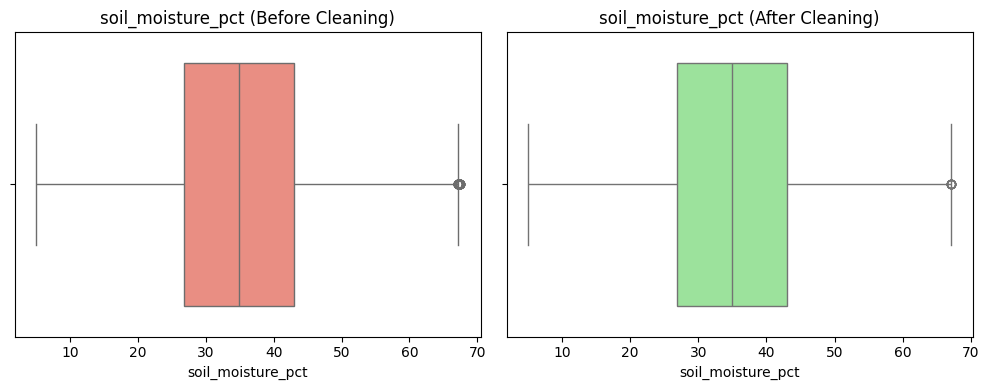


   -> Kolom 'soil_temp_c': Terdeteksi 478 outlier.
      (Batas Normal: 11.80 s/d 38.20)
      [Contoh Baris Outlier untuk Tabel Laporan]:
      soil_temp_c
978          38.4
1219         38.3
1575         38.3


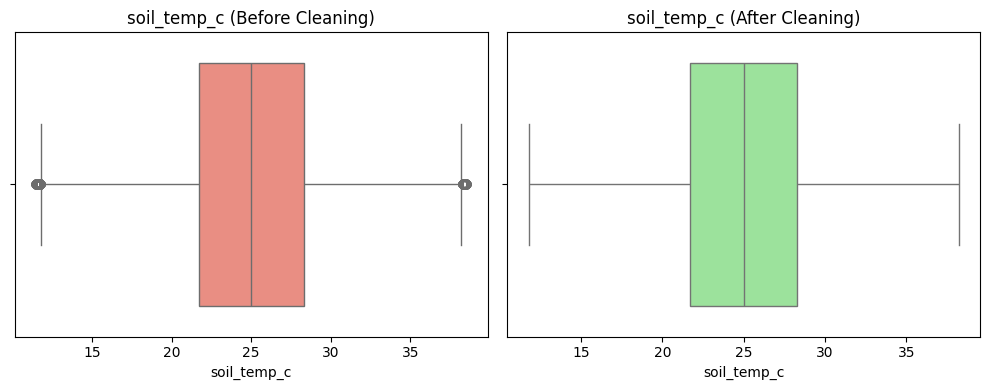


--- RINGKASAN AKHIR TAHAP 3 ---
Total Baris Awal      : 535773
Total Baris Bersih    : 535195
Data siap ditransformasi.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ASUMSI: df_selected sudah ada.
# Jika kamu mengulang dari awal, pastikan menjalankan kode Drop Tahap 2 dulu.
# df_selected = ...

print("--- Memulai Tahap 3: Data Pre-processing & Cleaning ---\n")

# 1 & 2. (Missing Value & Inkonsistensi - Sama seperti sebelumnya)
print("1. DETEKSI MISSING VALUES:")
if df_selected.isnull().sum().sum() == 0:
    print("   -> Laporan: Tidak ditemukan nilai kosong (0 Null).\n")

print("2. DETEKSI INKONSISTENSI FORMAT TEKS:")
kolom_kategorikal = ['soil_type', 'moisture_regime', 'thermal_regime', 'plant_category']
for col in kolom_kategorikal:
    df_selected[col] = df_selected[col].astype(str).str.lower().str.strip()
print("   -> Laporan: Normalisasi preventif selesai.\n")

# 3. DETEKSI DATA DUPLIKAT (TAHAPAN BARU)
print("3. DETEKSI DATA DUPLIKAT:")
jumlah_duplikat = df_selected.duplicated().sum()
print(f"   -> Terdeteksi {jumlah_duplikat} baris duplikat.")
if jumlah_duplikat > 0:
    df_selected = df_selected.drop_duplicates()
    print("   -> Aksi: Baris duplikat berhasil dihapus.\n")
else:
    print("   -> Aksi: Tidak ada duplikat yang dihapus.\n")

# 4. DETEKSI, VISUALISASI, & PENGHAPUSAN OUTLIER
print("4. DETEKSI OUTLIER (METODE IQR):")
kolom_numerik_sensor = ['soil_moisture_pct', 'soil_temp_c', 'air_temp_c', 'light_intensity_par']

baris_sebelum = df_selected.shape[0]

for col in kolom_numerik_sensor:
    Q1 = df_selected[col].quantile(0.25)
    Q3 = df_selected[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mencari baris outlier
    outlier_rows = df_selected[(df_selected[col] < lower_bound) | (df_selected[col] > upper_bound)]
    jumlah_outlier = len(outlier_rows)

    if jumlah_outlier > 0:
        print(f"\n   -> Kolom '{col}': Terdeteksi {jumlah_outlier} outlier.")
        print(f"      (Batas Normal: {lower_bound:.2f} s/d {upper_bound:.2f})")

        # INI UNTUK TABEL LAPORANMU: Cetak 3 sampel baris outlier beserta nomor index-nya
        print(f"      [Contoh Baris Outlier untuk Tabel Laporan]:")
        print(outlier_rows[[col]].head(3))

        # VISUALISASI SEBELUM DIBERSIHKAN
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.boxplot(x=df_selected[col], color='salmon')
        plt.title(f'{col} (Before Cleaning)')

        # EKSEKUSI PENGHAPUSAN
        df_selected = df_selected[(df_selected[col] >= lower_bound) & (df_selected[col] <= upper_bound)]

        # VISUALISASI SETELAH DIBERSIHKAN
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df_selected[col], color='lightgreen')
        plt.title(f'{col} (After Cleaning)')

        plt.tight_layout()
        plt.show() # Gambar akan muncul di sini

baris_sesudah = df_selected.shape[0]

print(f"\n--- RINGKASAN AKHIR TAHAP 3 ---")
print(f"Total Baris Awal      : {baris_sebelum}")
print(f"Total Baris Bersih    : {baris_sesudah}")
print("Data siap ditransformasi.")

  TAHAP 3: DATA PRE-PROCESSING & CLEANING

[1] DETEKSI MISSING VALUES
                 Atribut  Jumlah Missing Value
               soil_type                     0
            bulk_density                     0
      organic_matter_pct                     0
cation_exchange_capacity                     0
             salinity_ec                     0
      buffering_capacity                     0
       soil_moisture_pct                     0
      moisture_limit_dry                     0
      moisture_limit_wet                     0
         moisture_regime                     0
             soil_temp_c                     0
              air_temp_c                     0
          thermal_regime                     0
     light_intensity_par                     0
          plant_category                     0
            stress_level                     0
------------------------------------------------------------

[2] DETEKSI DATA DUPLIKAT
               Keterangan  Jumlah
    Total

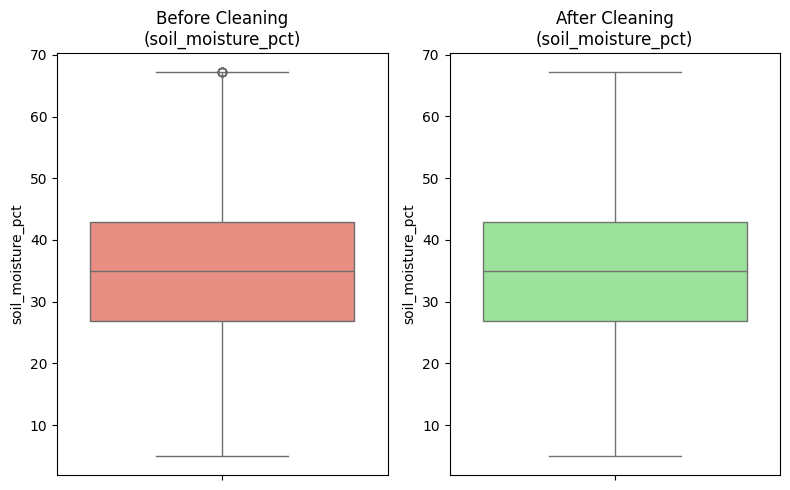

  RINGKASAN AKHIR TAHAP 3
Total Baris Awal      : 535195
Total Outlier Dihapus : 8
Total Baris Bersih    : 535187
Status                : SIAP DITRANSFORMASI


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ASUMSI: df_selected sudah ada dari Tahap 2 (yang berjumlah 543.210 baris)
# df_selected = ...

print("="*60)
print("  TAHAP 3: DATA PRE-PROCESSING & CLEANING")
print("="*60)

# ==========================================
# 1. Pengecekan Missing Values (Output Tabel)
# ==========================================
print("\n[1] DETEKSI MISSING VALUES")
# Membuat dataframe khusus untuk laporan missing value
df_missing = pd.DataFrame({
    'Atribut': df_selected.columns,
    'Jumlah Missing Value': df_selected.isnull().sum().values
})
print(df_missing.to_string(index=False))
print("-" * 60)

# ==========================================
# 2. Pengecekan Duplikasi Data (Output Tabel)
# ==========================================
print("\n[2] DETEKSI DATA DUPLIKAT")
jumlah_duplikat = df_selected.duplicated().sum()
df_duplikat = pd.DataFrame([
    {'Keterangan': 'Total Baris Observasi', 'Jumlah': len(df_selected)},
    {'Keterangan': 'Baris Duplikat Terdeteksi', 'Jumlah': jumlah_duplikat}
])
print(df_duplikat.to_string(index=False))

# Eksekusi Hapus Duplikat jika ada
if jumlah_duplikat > 0:
    df_selected = df_selected.drop_duplicates()
    print("-> Aksi: Baris duplikat berhasil dihapus.")
else:
    print("-> Aksi: Melewati penghapusan (0 duplikat).")
print("-" * 60)

# ==========================================
# 3. Pengecekan Inkonsistensi Teks (Output Tabel)
# ==========================================
print("\n[3] DETEKSI INKONSISTENSI FORMAT TEKS")
kolom_kategorikal = ['soil_type', 'moisture_regime', 'thermal_regime', 'plant_category']
data_inkonsisten = []

for col in kolom_kategorikal:
    # Cek yang teksnya tidak murni lowercase atau punya spasi ujung
    jumlah_inkon = (df_selected[col] != df_selected[col].astype(str).str.lower().str.strip()).sum()
    data_inkonsisten.append({'Atribut': col, 'Jumlah Inkonsisten': jumlah_inkon})

df_inkonsisten = pd.DataFrame(data_inkonsisten)
print(df_inkonsisten.to_string(index=False))

# Eksekusi Pembersihan
print("-> Aksi: Melakukan normalisasi format (lowercase & strip) pada atribut kategorikal...")
for col in kolom_kategorikal:
    df_selected[col] = df_selected[col].astype(str).str.lower().str.strip()
print("-" * 60)

# ==========================================
# 4. Pengecekan & Visualisasi Outlier
# ==========================================
print("\n[4] DETEKSI OUTLIER (Metode IQR)")
kolom_numerik_sensor = ['soil_moisture_pct', 'soil_temp_c', 'air_temp_c', 'light_intensity_par']
data_outlier_summary = []
dict_outlier_rows = {} # Untuk menyimpan baris outlier

baris_sebelum = df_selected.shape[0]

# Menghitung jumlah outlier dulu untuk masuk ke tabel
for col in kolom_numerik_sensor:
    Q1 = df_selected[col].quantile(0.25)
    Q3 = df_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mencari baris outlier
    outlier_slice = df_selected[(df_selected[col] < lower_bound) | (df_selected[col] > upper_bound)]
    jumlah_outlier = len(outlier_slice)

    data_outlier_summary.append({
        'Atribut': col,
        'Jumlah Outlier Terdeteksi': jumlah_outlier
    })

    # Simpan datanya jika ada outlier untuk di-print nanti
    if jumlah_outlier > 0:
        dict_outlier_rows[col] = {
            'data': outlier_slice,
            'lower': lower_bound,
            'upper': upper_bound
        }

# Cetak Tabel Summary Outlier
df_outlier_summary = pd.DataFrame(data_outlier_summary)
print(df_outlier_summary.to_string(index=False))
print("\n")

# Eksekusi Visualisasi, Cetak Index, dan Penghapusan
for col, info in dict_outlier_rows.items():
    print(f"--- Rincian Outlier pada '{col}' ---")
    print(f"Batas Normal: {info['lower']:.2f} s/d {info['upper']:.2f}")

    # Cetak 10 contoh baris beserta index-nya
    print(f"\nContoh (Maksimal 10 Baris) Outlier:")
    contoh_outlier = info['data'][[col]].head(10)
    print(contoh_outlier)
    print("\n")

    # Visualisasi Boxplot VERTIKAL (y=...)
    plt.figure(figsize=(8, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_selected[col], color='salmon')
    plt.title(f'Before Cleaning\n({col})')

    # Proses Penghapusan Outlier untuk kolom ini
    df_selected = df_selected[(df_selected[col] >= info['lower']) & (df_selected[col] <= info['upper'])]

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_selected[col], color='lightgreen')
    plt.title(f'After Cleaning\n({col})')

    plt.tight_layout()
    plt.show()

baris_sesudah = df_selected.shape[0]

print("="*60)
print("  RINGKASAN AKHIR TAHAP 3")
print("="*60)
print(f"Total Baris Awal      : {baris_sebelum}")
print(f"Total Outlier Dihapus : {baris_sebelum - baris_sesudah}")
print(f"Total Baris Bersih    : {baris_sesudah}")
print("Status                : SIAP DITRANSFORMASI")
print("="*60)

# Data Transformation

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Asumsi: df_selected adalah data bersih dari Tahap 3
# df_selected = ...

print("="*60)
print(" TAHAP 4: DATA TRANSFORMATION ")
print("="*60)

# Cetak 10 baris pertama SEBELUM transformasi
print("\n[1] PREVIEW DATA SEBELUM TRANSFORMASI (10 Baris Pertama):")
# Kita pilih beberapa kolom saja agar mudah dilihat di layar
kolom_preview = ['soil_type', 'soil_moisture_pct', 'air_temp_c', 'light_intensity_par', 'plant_category', 'stress_level']
print(df_selected[kolom_preview].head(10).to_string())

# Copy dataframe agar data asli tidak tertimpa sepenuhnya (best practice)
df_transformed = df_selected.copy()

# ==========================================
# 4.1 Categorical Encoding (Label Encoding)
# ==========================================
# Mendefinisikan kolom yang berisi teks
kolom_kategorikal = ['soil_type', 'moisture_regime', 'thermal_regime', 'plant_category']
le = LabelEncoder()

# Loop untuk mengubah setiap kolom teks menjadi angka
for col in kolom_kategorikal:
    df_transformed[col] = le.fit_transform(df_transformed[col])

# ==========================================
# 4.2 Feature Scaling (StandardScaler)
# ==========================================
# Mendefinisikan kolom numerik (SEMUA kolom KECUALI yang kategorikal dan target 'stress_level')
kolom_numerik = [col for col in df_transformed.columns if col not in kolom_kategorikal and col != 'stress_level']

scaler = StandardScaler()

# Melakukan standarisasi (Z-Score)
df_transformed[kolom_numerik] = scaler.fit_transform(df_transformed[kolom_numerik])

# Cetak 10 baris pertama SESUDAH transformasi
print("\n" + "="*60)
print("\n[2] PREVIEW DATA SESUDAH TRANSFORMASI (10 Baris Pertama):")
print("Keterangan: Teks telah menjadi integer, dan sensor terskala (mean~0, std=1)\n")
# Kita cetak dengan pembulatan 3 angka di belakang koma agar rapi
print(df_transformed[kolom_preview].head(10).round(3).to_string())

print("\n" + "="*60)
print(" TRANSFORMASI SELESAI. DATA SIAP DIMASUKKAN KE ALGORITMA ML.")
print(" Dimensi Data Akhir:", df_transformed.shape)
print("="*60)

 TAHAP 4: DATA TRANSFORMATION 

[1] PREVIEW DATA SEBELUM TRANSFORMASI (10 Baris Pertama):
  soil_type  soil_moisture_pct  air_temp_c  light_intensity_par plant_category  stress_level
0    clayey               5.17        25.6               1027.0      vegetable             1
1  alluvial              26.28        30.3                563.0      vegetable             0
2    chalky              44.90        34.1                408.0      vegetable             2
3     silty              27.05        30.2                729.0         cereal             1
4     loamy              36.56        25.9                339.0      vegetable             0
5     loamy              42.94        38.1                270.0      vegetable             1
6     sandy              49.41        33.3                373.0         cereal             1
7  laterite              38.02        32.9                636.0         legume             2
8     peaty              40.63        20.2               1160.0         l

# Machine Learning

  TAHAP 6: EKSPERIMEN MODELING (DECISION TREE & NAIVE BAYES)

>>> Memproses Decision Tree dengan GridSearchCV...
    Mencari hyperparameter terbaik... (mohon tunggu)

Fitting 3 folds for each of 90 candidates, totalling 270 fits

Parameter Terbaik: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV Score Terbaik : 0.65377

--- Hasil Evaluasi Decision Tree (Tuned) ---
Accuracy  : 0.65503
Precision : 0.66103
Recall    : 0.65503
F1-Score  : 0.65100

Confusion Matrix:
[[28178  6652    58]
 [13941 28743  4433]
 [  903 10938 13192]]


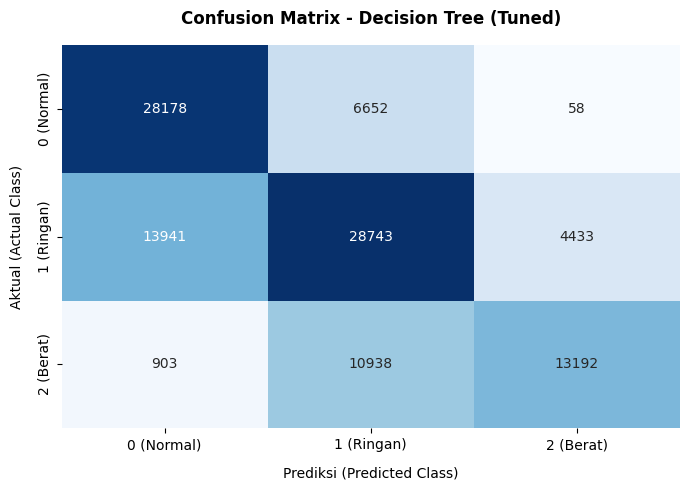

------------------------------------------------------------

>>> Memproses Naive Bayes dengan GridSearchCV...
    Mencari var_smoothing terbaik... (mohon tunggu)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Parameter Terbaik: {'var_smoothing': np.float64(0.0005298316906283702)}
CV Score Terbaik : 0.55313

--- Hasil Evaluasi Naive Bayes (Tuned) ---
Accuracy  : 0.55090
Precision : 0.55121
Recall    : 0.55090
F1-Score  : 0.54145

Confusion Matrix:
[[26319  5452  3117]
 [14802 18244 14071]
 [  973  9656 14404]]


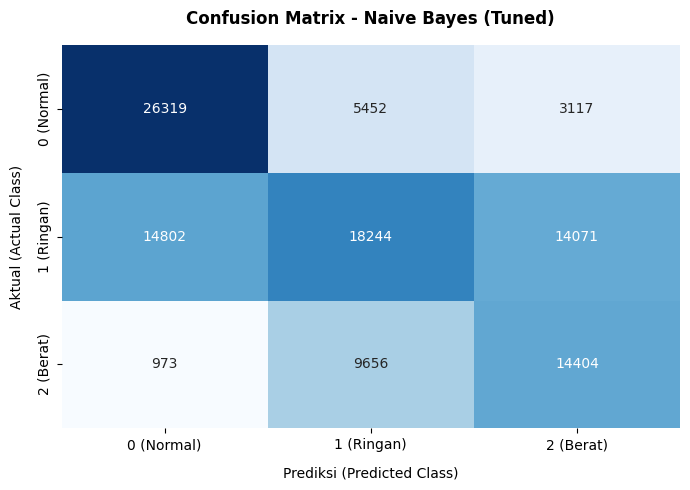


  RINGKASAN PERBANDINGAN
                Model  Accuracy  Precision  Recall  F1-Score
Decision Tree (Tuned)   0.65503    0.66103 0.65503   0.65100
  Naive Bayes (Tuned)   0.55090    0.55121 0.55090   0.54145

  EKSPERIMEN SELESAI

Model Decision Tree disimpan ke: ./models/decision_tree_tuned.pkl


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("  TAHAP 6: EKSPERIMEN MODELING (DECISION TREE & NAIVE BAYES)")
print("=" * 60)

# Fungsi visualisasi confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['0 (Normal)', '1 (Ringan)', '2 (Berat)'],
                yticklabels=['0 (Normal)', '1 (Ringan)', '2 (Berat)'])
    plt.title(title, fontweight='bold', pad=15)
    plt.xlabel('Prediksi (Predicted Class)', labelpad=10)
    plt.ylabel('Aktual (Actual Class)', labelpad=10)
    plt.tight_layout()
    plt.show()

# ==========================================
# MODEL 1: DECISION TREE (TUNED)
# ==========================================
print("\n>>> Memproses Decision Tree dengan GridSearchCV...")
print("    Mencari hyperparameter terbaik... (mohon tunggu)\n")

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

print(f"\nParameter Terbaik: {dt_grid.best_params_}")
print(f"CV Score Terbaik : {dt_grid.best_score_:.5f}")

print("\n--- Hasil Evaluasi Decision Tree (Tuned) ---")
print(f"Accuracy  : {accuracy_score(y_test, dt_pred):.5f}")
print(f"Precision : {precision_score(y_test, dt_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, dt_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, dt_pred, average='weighted'):.5f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

# Visualisasi
plot_confusion_matrix(y_test, dt_pred, 'Confusion Matrix - Decision Tree (Tuned)')

print("-" * 60)

# ==========================================
# MODEL 2: NAIVE BAYES (TUNED)
# ==========================================
print("\n>>> Memproses Naive Bayes dengan GridSearchCV...")
print("    Mencari var_smoothing terbaik... (mohon tunggu)\n")

nb_param_grid = {
    'var_smoothing': np.logspace(-12, -1, 30)
}

nb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)
nb_grid.fit(X_train, y_train)

nb_best = nb_grid.best_estimator_
nb_pred = nb_best.predict(X_test)

print(f"\nParameter Terbaik: {nb_grid.best_params_}")
print(f"CV Score Terbaik : {nb_grid.best_score_:.5f}")

print("\n--- Hasil Evaluasi Naive Bayes (Tuned) ---")
print(f"Accuracy  : {accuracy_score(y_test, nb_pred):.5f}")
print(f"Precision : {precision_score(y_test, nb_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, nb_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, nb_pred, average='weighted'):.5f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

# Visualisasi
plot_confusion_matrix(y_test, nb_pred, 'Confusion Matrix - Naive Bayes (Tuned)')

# ==========================================
# RINGKASAN
# ==========================================
print("\n" + "=" * 60)
print("  RINGKASAN PERBANDINGAN")
print("=" * 60)

results = pd.DataFrame({
    'Model': ['Decision Tree (Tuned)', 'Naive Bayes (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, nb_pred)
    ],
    'Precision': [
        precision_score(y_test, dt_pred, average='weighted'),
        precision_score(y_test, nb_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, dt_pred, average='weighted'),
        recall_score(y_test, nb_pred, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, dt_pred, average='weighted'),
        f1_score(y_test, nb_pred, average='weighted')
    ]
})
print(results.round(5).to_string(index=False))
print("\n" + "=" * 60)
print("  EKSPERIMEN SELESAI")
print("=" * 60)
import joblib
import os

# Buat folder models jika belum ada
os.makedirs('./models', exist_ok=True)

# Simpan model Decision Tree terbaik
joblib.dump(dt_best, './models/decision_tree_tuned.pkl')
print(f"\nModel Decision Tree disimpan ke: ./models/decision_tree_tuned.pkl")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ASUMSI: df_transformed adalah dataset hasil dari Tahap 4 (Encoding & Scaling)
X = df_transformed.drop(columns=['stress_level'])
y = df_transformed['stress_level']

print("="*60)
print("  TAHAP 5: EKSPERIMEN ADVANCED MODELING (ENSEMBLE)")
print("="*60)

# Membagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Training) : {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Testing)    : {X_test.shape[0]} baris\n")

# ==========================================
# 3. Model Random Forest
# ==========================================
print("[1] Memproses Model Random Forest (Mohon tunggu, memakan waktu 1-3 menit)...")
# n_estimators=100 (membuat 100 pohon), n_jobs=-1 (pakai semua CPU core)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("--- Hasil Evaluasi Random Forest ---")
print(f"Accuracy  : {accuracy_score(y_test, rf_pred):.5f}")
print(f"Precision : {precision_score(y_test, rf_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, rf_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, rf_pred, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("-" * 60)

# ==========================================
# 4. Model XGBoost
# ==========================================
print("\n[2] Memproses Model XGBoost (Mohon tunggu)...")
# XGBoost sangat efisien untuk data numerik matriks
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("--- Hasil Evaluasi XGBoost ---")
print(f"Accuracy  : {accuracy_score(y_test, xgb_pred):.5f}")
print(f"Precision : {precision_score(y_test, xgb_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, xgb_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, xgb_pred, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("="*60)
print(" EKSPERIMEN SELESAI ")
print("="*60)

  TAHAP 5: EKSPERIMEN ADVANCED MODELING (ENSEMBLE)
Jumlah Data Latih (Training) : 428156 baris
Jumlah Data Uji (Testing)    : 107039 baris

[1] Memproses Model Random Forest (Mohon tunggu, memakan waktu 1-3 menit)...
--- Hasil Evaluasi Random Forest ---
Accuracy  : 0.62880
Precision : 0.63078
Recall    : 0.62880
F1-Score  : 0.62683
Confusion Matrix:
[[25714  8767   408]
 [13200 28035  5882]
 [ 1081 10395 13557]]
------------------------------------------------------------

[2] Memproses Model XGBoost (Mohon tunggu)...
--- Hasil Evaluasi XGBoost ---
Accuracy  : 0.65748
Precision : 0.66428
Recall    : 0.65748
F1-Score  : 0.65392
Confusion Matrix:
[[27945  6898    46]
 [13679 29196  4242]
 [  844 10954 13235]]
 EKSPERIMEN SELESAI 


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ASUMSI: X dan y sudah didefinisikan dari df_transformed sebelumnya
# X = df_transformed.drop(columns=['stress_level'])
# y = df_transformed['stress_level']

print("="*60)
print("  TAHAP 5: EKSPERIMEN KELAS BERAT (TUNING & NEURAL NETWORK)")
print("="*60)

# Membagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Training) : {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Testing)    : {X_test.shape[0]} baris\n")

# ==========================================
# 1. Model LightGBM dengan Hyperparameter Tuning
# ==========================================
print("[1] Memproses LightGBM dengan Hyperparameter Tuning...")
print("    (Mencari kombinasi parameter terbaik, mohon tunggu...)")

lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

# Daftar "tombol" yang akan diacak dan diuji oleh mesin
param_grid_lgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [7, 10, 15, -1],
    'num_leaves': [31, 63, 127]
}

# Mencari kombinasi terbaik (diuji 5 iterasi kombinasi agar komputasi tidak over)
random_search_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid_lgb,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Melatih model dengan kombinasi parameter
random_search_lgb.fit(X_train, y_train)

# Menggunakan model dengan parameter terbaik untuk menebak data uji
best_lgb = random_search_lgb.best_estimator_
lgb_pred = best_lgb.predict(X_test)

print("\n--- Hasil Evaluasi Tuned LightGBM ---")
print(f"Setelan Terbaik yang Ditemukan: {random_search_lgb.best_params_}")
print(f"Accuracy  : {accuracy_score(y_test, lgb_pred):.5f}")
print(f"Precision : {precision_score(y_test, lgb_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, lgb_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, lgb_pred, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, lgb_pred))
print("-" * 60)

# ==========================================
# 2. Model Neural Network (Multi-Layer Perceptron)
# ==========================================
print("\n[2] Memproses Neural Network (Multi-Layer Perceptron)...")
print("    (Melatih arsitektur jaringan saraf, mohon tunggu...)")

# Arsitektur: 2 hidden layers (128 neuron di layer pertama, 64 di layer kedua)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True # Otomatis berhenti jika sudah tidak ada peningkatan
)

mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

print("\n--- Hasil Evaluasi Neural Network (MLP) ---")
print(f"Accuracy  : {accuracy_score(y_test, mlp_pred):.5f}")
print(f"Precision : {precision_score(y_test, mlp_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, mlp_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, mlp_pred, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, mlp_pred))
print("="*60)
print(" EKSPERIMEN SELESAI ")
print("="*60)

  TAHAP 5: EKSPERIMEN KELAS BERAT (TUNING & NEURAL NETWORK)
Jumlah Data Latih (Training) : 428156 baris
Jumlah Data Uji (Testing)    : 107039 baris

[1] Memproses LightGBM dengan Hyperparameter Tuning...
    (Mencari kombinasi parameter terbaik, mohon tunggu...)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- Hasil Evaluasi Tuned LightGBM ---
Setelan Terbaik yang Ditemukan: {'num_leaves': 127, 'n_estimators': 100, 'max_depth': 15, 'learning_rate': 0.05}
Accuracy  : 0.65756
Precision : 0.66437
Recall    : 0.65756
F1-Score  : 0.65385
Confusion Matrix:
[[28054  6786    49]
 [13767 29112  4238]
 [  884 10930 13219]]
------------------------------------------------------------

[2] Memproses Neural Network (Multi-Layer Perceptron)...
    (Melatih arsitektur jaringan saraf, mohon tunggu...)

--- Hasil Evaluasi Neural Network (MLP) ---
Accuracy  : 0.65771
Precision : 0.66443
Recall    : 0.65771
F1-Score  : 0.65397
Confusion Matrix:
[[28088  6756    45]
 [13783 29076  4258]
 [

  TAHAP 5: EKSPERIMEN DATA MINING DENGAN VISUALISASI
Distribusi Data: 428156 Training, 107039 Testing

>>> Memproses Model Decision Tree...

--- Hasil Metrik Decision Tree ---
Accuracy  : 0.54368
Precision : 0.54388
Recall    : 0.54368
F1-Score  : 0.54376



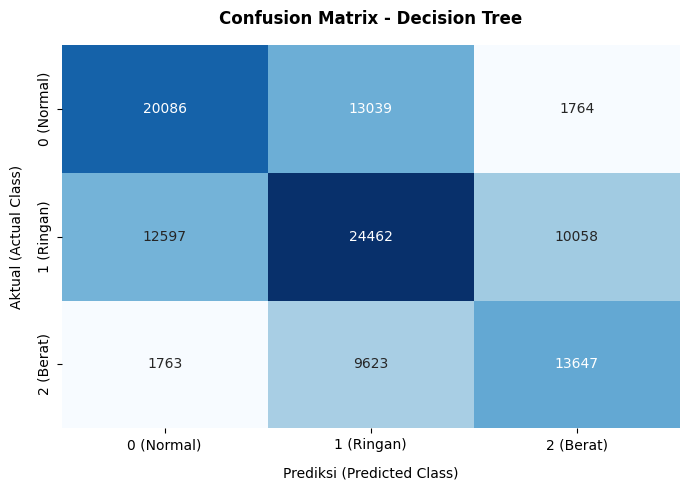

------------------------------------------------------------
>>> Memproses Model Naive Bayes...

--- Hasil Metrik Naive Bayes ---
Accuracy  : 0.55129
Precision : 0.55210
Recall    : 0.55129
F1-Score  : 0.54190



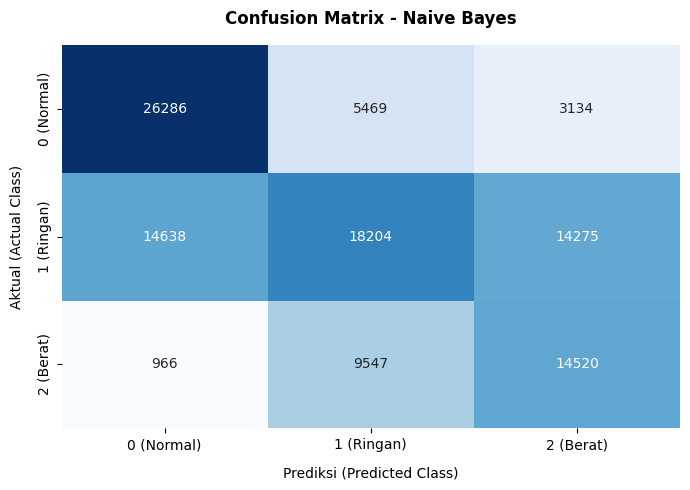

  EKSPERIMEN & VISUALISASI SELESAI


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ASUMSI: df_transformed adalah dataset hasil dari Tahap 4
# Pastikan X dan y sudah didefinisikan sebelumnya
X = df_transformed.drop(columns=['stress_level'])
y = df_transformed['stress_level']

print("="*60)
print("  TAHAP 5: EKSPERIMEN DATA MINING DENGAN VISUALISASI")
print("="*60)

# 1. Membagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Distribusi Data: {X_train.shape[0]} Training, {X_test.shape[0]} Testing\n")

# Fungsi Bantuan untuk Visualisasi Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    # Membuat figure baru untuk setiap grafik
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['0 (Normal)', '1 (Ringan)', '2 (Berat)'],
                yticklabels=['0 (Normal)', '1 (Ringan)', '2 (Berat)'])
    plt.title(title, fontweight='bold', pad=15)
    plt.xlabel('Prediksi (Predicted Class)', labelpad=10)
    plt.ylabel('Aktual (Actual Class)', labelpad=10)
    plt.tight_layout()
    plt.show() # Langsung tampilkan gambar di sini

# ==========================================
# MODEL 1: DECISION TREE
# ==========================================
print(">>> Memproses Model Decision Tree...\n")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Cetak Metrik Teks
print("--- Hasil Metrik Decision Tree ---")
print(f"Accuracy  : {accuracy_score(y_test, dt_pred):.5f}")
print(f"Precision : {precision_score(y_test, dt_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, dt_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, dt_pred, average='weighted'):.5f}\n")

# Cetak Gambar Matriks Decision Tree
plot_confusion_matrix(y_test, dt_pred, 'Confusion Matrix - Decision Tree')

print("-" * 60)

# ==========================================
# MODEL 2: NAIVE BAYES
# ==========================================
print(">>> Memproses Model Naive Bayes...\n")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Cetak Metrik Teks
print("--- Hasil Metrik Naive Bayes ---")
print(f"Accuracy  : {accuracy_score(y_test, nb_pred):.5f}")
print(f"Precision : {precision_score(y_test, nb_pred, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, nb_pred, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, nb_pred, average='weighted'):.5f}\n")

# Cetak Gambar Matriks Naive Bayes
plot_confusion_matrix(y_test, nb_pred, 'Confusion Matrix - Naive Bayes')

print("="*60)
print("  EKSPERIMEN & VISUALISASI SELESAI")
print("="*60)

# Data Balancing Data

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter

# ASUMSI: X_train, X_test, y_train, y_test sudah ada dari proses pembagian data sebelumnya

print("="*60)
print("  EKSPERIMEN LANJUTAN: DATA BALANCING & AUGMENTATION")
print("="*60)

print("\n[1] Distribusi Kelas Data Latih SEBELUM Balancing:")
counter_before = Counter(y_train)
for k, v in counter_before.items():
    print(f" - Kelas {k}: {v} baris")

# ==========================================
# PROSES AUGMENTASI SINTETIK (SMOTE)
# ==========================================
print("\n[2] Memproses Augmentasi Data Sintetik (SMOTE)...")
print("    (Membangun data baru berbasis KNN, mohon tunggu...)")

# Inisiasi SMOTE
smote = SMOTE(random_state=42)

# PERHATIAN: Balancing HANYA dilakukan pada Data Latih (Training Set)
# Data Uji (Testing Set) harus tetap asli agar evaluasi objektif
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\n[3] Distribusi Kelas Data Latih SETELAH SMOTE:")
counter_after = Counter(y_train_balanced)
for k, v in counter_after.items():
    print(f" - Kelas {k}: {v} baris (Seimbang!)")

print("\n" + "-"*60)

# ==========================================
# MELATIH ULANG MODEL DENGAN DATA BALANCED
# ==========================================
print("\n>>> Melatih Ulang Decision Tree dengan Data Sintetik...")
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_balanced, y_train_balanced)
dt_pred_smote = dt_smote.predict(X_test)

print("--- Hasil Evaluasi Decision Tree (SMOTE) ---")
print(f"Accuracy  : {accuracy_score(y_test, dt_pred_smote):.5f}")
print(f"Precision : {precision_score(y_test, dt_pred_smote, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, dt_pred_smote, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, dt_pred_smote, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred_smote))

print("\n" + "-"*60)

print("\n>>> Melatih Ulang Naive Bayes dengan Data Sintetik...")
nb_smote = GaussianNB()
nb_smote.fit(X_train_balanced, y_train_balanced)
nb_pred_smote = nb_smote.predict(X_test)

print("--- Hasil Evaluasi Naive Bayes (SMOTE) ---")
print(f"Accuracy  : {accuracy_score(y_test, nb_pred_smote):.5f}")
print(f"Precision : {precision_score(y_test, nb_pred_smote, average='weighted'):.5f}")
print(f"Recall    : {recall_score(y_test, nb_pred_smote, average='weighted'):.5f}")
print(f"F1-Score  : {f1_score(y_test, nb_pred_smote, average='weighted'):.5f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred_smote))

print("\n" + "="*60)
print("  EKSPERIMEN DATA BALANCING SELESAI")
print("="*60)

  EKSPERIMEN LANJUTAN: DATA BALANCING & AUGMENTATION

[1] Distribusi Kelas Data Latih SEBELUM Balancing:
 - Kelas 1: 188469 baris
 - Kelas 2: 100133 baris
 - Kelas 0: 139554 baris

[2] Memproses Augmentasi Data Sintetik (SMOTE)...
    (Membangun data baru berbasis KNN, mohon tunggu...)

[3] Distribusi Kelas Data Latih SETELAH SMOTE:
 - Kelas 1: 188469 baris (Seimbang!)
 - Kelas 2: 188469 baris (Seimbang!)
 - Kelas 0: 188469 baris (Seimbang!)

------------------------------------------------------------

>>> Melatih Ulang Decision Tree dengan Data Sintetik...
--- Hasil Evaluasi Decision Tree (SMOTE) ---
Accuracy  : 0.53856
Precision : 0.53845
Recall    : 0.53856
F1-Score  : 0.53765
Confusion Matrix:
[[20663 11919  2307]
 [13109 22557 11451]
 [ 1789  8817 14427]]

------------------------------------------------------------

>>> Melatih Ulang Naive Bayes dengan Data Sintetik...
--- Hasil Evaluasi Naive Bayes (SMOTE) ---
Accuracy  : 0.52318
Precision : 0.54583
Recall    : 0.52318
F1-Score